In [34]:
import polars as pl
import matplotlib.pyplot as plt
import s3fs
import polars.selectors as cs
import numpy as np

In [8]:
def load_file(source):
    return pl.scan_parquet(
        source,
        storage_options={
            "aws_endpoint_url": "https://minio.lab.sspcloud.fr",
            "aws_region": "us-east-1",
        },
        credential_provider=pl.CredentialProviderAWS(
            profile_name="default",
            region_name="us-east-1",
        ),
    ).collect()

## Taille d'échantillon

Erreur min à avoir : 0.5% -> 0.005
n = 40 000

Petit sondage: 1000
Gros sondage: 10 000

## Erreur moyenne sondages

In [9]:
polls2022 = load_file("s3://arthurmanceau/poll_tracker/wiki/presidentiel/2022/t1/polls.parquet")

In [10]:
error_cols = ['E_C_arthaud_processed',
    'E_C_poutou_processed',
    'E_C_roussel_processed',
    'E_C_melenchon_processed',
    'E_C_hidalgo_processed',
    'E_C_jadot_processed',
    'E_C_macron_processed',
    'E_C_pecresse_processed',
    'E_C_lassalle_processed',
    'E_C_dupont_aignan_processed',
    'E_C_m_le_pen_processed',
    'E_C_zemmour_processed'
]
meta_cols = [
    'end_date',
    'source',
    'sample_size']

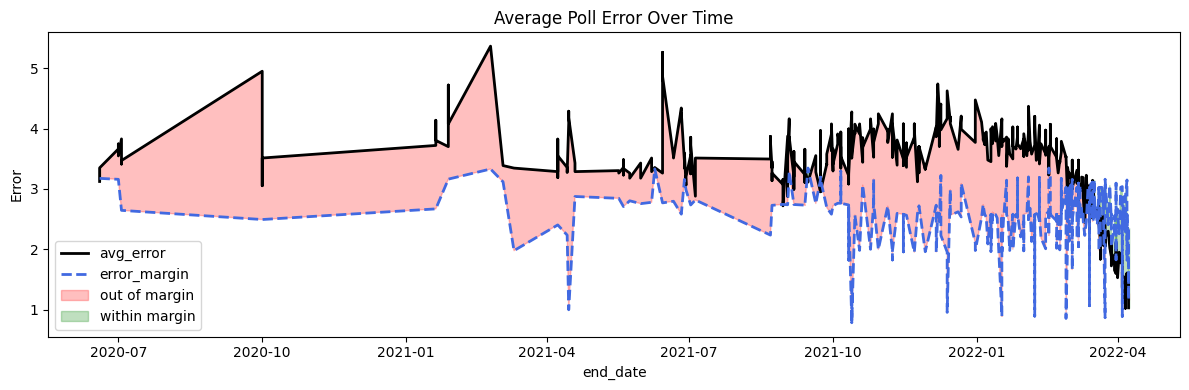

In [11]:
df_plot = (
    polls2022
    .sort("end_date")
    .select(meta_cols + error_cols)
    #.filter(pl.col("end_date") > pl.date(2022, 1, 1))
    .head(-1)
    .with_columns(
        error_margin = 1 / pl.col("sample_size").sqrt() * 100,
        *[pl.col(c).abs().alias(c) for c in error_cols],
    )
    .with_columns(
        avg_error = pl.mean_horizontal(*error_cols)
    )
    .select(meta_cols + ["avg_error", "error_margin"])
)

x = np.array(df_plot["end_date"].to_list())
y_avg = np.array(df_plot["avg_error"].to_list(), dtype=float)
y_margin = np.array(df_plot["error_margin"].to_list(), dtype=float)

# valid rows only
m = np.isfinite(y_avg) & np.isfinite(y_margin)
x, y_avg, y_margin = x[m], y_avg[m], y_margin[m]

above = y_avg > y_margin      # out of margin -> red
below = y_avg <= y_margin     # within margin -> green

plt.figure(figsize=(12, 4))
plt.plot(x, y_avg, label="avg_error", linewidth=2, color="black")
plt.plot(x, y_margin, label="error_margin", linewidth=2, linestyle="--", color="royalblue")

plt.fill_between(x, y_avg, y_margin, where=above, interpolate=True, color="red", alpha=0.25, label="out of margin")
plt.fill_between(x, y_avg, y_margin, where=below, interpolate=True, color="green", alpha=0.25, label="within margin")

plt.title("Average Poll Error Over Time")
plt.xlabel("end_date")
plt.ylabel("Error")
plt.legend()
plt.tight_layout()
plt.show()

Fiable seulement à quelques jours de l'election (1 mois avant)

## Réajustement previous vote (méthode)

In [13]:
pollllm2022 = (
    pl.scan_csv(
        "s3://arthurmanceau/poll_llm/results/3/gemma4-26b-moe/2022/100/detailed.csv",
        storage_options={
            "aws_endpoint_url": "https://minio.lab.sspcloud.fr",
            "aws_region": "us-east-1",
            'profile':'default'
        },
    )
    .collect()
)

In [18]:
# True : 83,61%
pollllm2022.filter(pl.col('inscription')=='Oui').select('probabilite').mean() * 10

probabilite
f64
83.977273


In [31]:
X = pollllm2022.filter(
    pl.col('inscription')=='Oui'
).with_columns(
    n=len(pollllm2022.filter( pl.col('inscription')=='Oui'))
).group_by(
    'previous_vote2022'
).agg(
    pl.len().alias('vote'),
    pl.col('n').max()).with_columns(
    pvote = (pl.col('vote') / pl.col('n')) *100
)
X

previous_vote2022,vote,n,pvote
str,u32,i32,f64
"""Benoît Hamon (Parti Socialiste…",1,88,1.136364
"""Marine Le Pen (Rassemblement n…",14,88,15.909091
"""François Fillon (Les Républica…",31,88,35.227273
"""Emmanuel Macron (La République…",32,88,36.363636
"""Jean-Luc Mélenchon (La France …",10,88,11.363636


In [33]:
X.get_column('previous_vote2022').to_list()

['Benoît Hamon (Parti Socialiste)',
 'Marine Le Pen (Rassemblement national)',
 'François Fillon (Les Républicains)',
 'Emmanuel Macron (La République en marche)',
 'Jean-Luc Mélenchon (La France insoumise)']

In [37]:
resultat2017 = load_file("s3://arthurmanceau/poll_tracker/wiki/presidentiel/2017/t1/polls.parquet").filter(pl.col('source')=='Résultats').select(cs.contains("processed"))
resultat2017

C_abstention_processed,C_indecis_processed,C_arthaud_processed,C_poutou_processed,C_melenchon_processed,C_hamon_processed,C_macron_processed,C_lassalle_processed,C_fillon_processed,C_dupont_aignan_processed,C_asselineau_processed,C_m_le_pen_processed,C_cheminade_processed,C_others_processed,C_jadot_processed,C_bayrou_processed,C_montebourg_processed,C_peillon_processed,C_valls_processed,C_pinel_processed,C_hollande_processed,C_juppe_processed,C_sarkozy_processed,C_duflot_processed,C_le_maire_processed,C_hուլot_processed,C_besancenot_processed,C_de_villiers_processed,C_joly_processed,C_aubry_processed,C_cope_processed,E_C_abstention_processed,E_C_indecis_processed,E_C_arthaud_processed,E_C_poutou_processed,E_C_melenchon_processed,E_C_hamon_processed,E_C_macron_processed,E_C_lassalle_processed,E_C_fillon_processed,E_C_dupont_aignan_processed,E_C_asselineau_processed,E_C_m_le_pen_processed,E_C_cheminade_processed,E_C_others_processed,E_C_jadot_processed,E_C_bayrou_processed,E_C_montebourg_processed,E_C_peillon_processed,E_C_valls_processed,E_C_pinel_processed,E_C_hollande_processed,E_C_juppe_processed,E_C_sarkozy_processed,E_C_duflot_processed,E_C_le_maire_processed,E_C_hուլot_processed,E_C_besancenot_processed,E_C_de_villiers_processed,E_C_joly_processed,E_C_aubry_processed,E_C_cope_processed
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
22.23,0.0,0.64,1.09,19.58,6.36,24.01,1.21,20.01,4.7,0.92,21.3,0.18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
